# A "global" normalizing flow on the sphere $S^2$

Geophysical and astronomical data live on the sphere. This notebook builds a
normalizing flow on $S^2 \subset \mathbb{R}^3$ via **stereographic projection**:
we map the sphere to the plane (with an explicit Jacobian), fit a flowjax
spline coupling on the plane, and pull the density back to $S^2$ to plot it
in a Mollweide projection.

The target is a synthetic stand-in for "global hotspots": a mixture of three
[von Mises–Fisher (VMF)](https://en.wikipedia.org/wiki/Von_Mises%E2%80%93Fisher_distribution)
distributions concentrated at three different points on the sphere.

**Limitations.** Stereographic projection has a singularity at the north
pole: points near it map to large $\mathbb{R}^2$ values and the Jacobian
blows up. We pick the projection point so that the data clusters lie away
from the singularity. Tangent-space (`expmap`) flows avoid this at the cost
of losing the global bijection to $\mathbb{R}^2$ — a topic for a future
notebook.

In [1]:
from __future__ import annotations

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns
from flowjax.bijections import Chain, Permute
from flowjax.distributions import Normal, Transformed
from flowjax.train import fit_to_data

from gauss_flows import RQSplineCoupling, VonMisesFisher

sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.constrained_layout.use": True,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.titleweight": "semibold",
    }
)


def style_axes(ax, *, aspect=None):
    ax.minorticks_on()
    ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


palette = sns.color_palette("deep")

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. A VMF-mixture target on $S^2$

Three modes at chosen unit vectors with concentration $\kappa = 30$ (tight
clusters). We use **north-pole** stereographic projection (singularity at
$x_3 = 1$, see section 2). The mode means are placed in the *southern*
hemisphere ($x_3 < 0$) so the data maps to a compact region near the
origin in $\mathbb{R}^2$ — well away from the singularity.

In [2]:
key = jr.key(0)
data_key, train_key, sample_key = jr.split(key, 3)


def normalize(v: jnp.ndarray) -> jnp.ndarray:
    return v / jnp.linalg.norm(v)


# Three "hotspots" — pick mean directions in the southern hemisphere
# (z < 0) so they land near the origin under north-pole stereographic
# projection (denominator 1 - z is large for z < 0, so |sigma(x)| stays small).
mode_means = jnp.stack(
    [
        normalize(jnp.array([0.6, 0.2, -0.8])),
        normalize(jnp.array([-0.5, 0.7, -0.5])),
        normalize(jnp.array([0.0, -0.9, -0.3])),
    ]
)
mode_weights = jnp.array([0.4, 0.35, 0.25])
mode_concentration = 30.0
n_modes = mode_means.shape[0]

n_samples = 3000
mix_keys = jr.split(data_key, 2)
component = jr.choice(mix_keys[0], n_modes, shape=(n_samples,), p=mode_weights)
sub_keys = jr.split(mix_keys[1], n_samples)


def sample_from_mode(mode_idx: jnp.ndarray, sub_key) -> jnp.ndarray:
    mu = mode_means[mode_idx]
    return VonMisesFisher(mu, mode_concentration).sample(sub_key)


sphere_data = jax.vmap(sample_from_mode)(component, sub_keys)
print("data shape:", sphere_data.shape)
print(
    "on-sphere check max |‖x‖ - 1|:",
    float(jnp.max(jnp.abs(jnp.linalg.norm(sphere_data, axis=-1) - 1.0))),
)

data shape: (3000, 3)


on-sphere check max |‖x‖ - 1|: 1.1920928955078125e-07


## 2. Stereographic projection $S^2 \leftrightarrow \mathbb{R}^2$

Project from the north pole $N = (0, 0, 1)$. For a point $x = (x_1, x_2, x_3)$
on $S^2$ with $x_3 \neq 1$ the forward map and its inverse are

$$\sigma(x) = \frac{1}{1 - x_3}\,(x_1,\, x_2), \qquad
  \sigma^{-1}(u) = \frac{1}{1 + \|u\|^2}\,(2u_1,\, 2u_2,\, \|u\|^2 - 1).$$

The Jacobian determinant of $\sigma$ from the canonical area form on $S^2$
to the Lebesgue measure on $\mathbb{R}^2$ is

$$\bigl|\det J_\sigma(x)\bigr| = \frac{1}{(1 - x_3)^2}, \qquad
  \bigl|\det J_{\sigma^{-1}}(u)\bigr| = \frac{4}{(1 + \|u\|^2)^2}.$$

Stereographic projection is a chart between manifolds of *different ambient
dimensions* (3 → 2 and back), so it can't be expressed as a `flowjax`
`AbstractBijection` (which requires matching shapes). We use plain JAX
functions and assemble the sphere flow functionally below.

In [3]:
def stereographic(x: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
    """Sphere → plane. Returns (u, log|det J_σ|) with the area-form Jacobian."""
    denom = 1.0 - x[2]
    u = jnp.stack([x[0] / denom, x[1] / denom])
    log_det = -2.0 * jnp.log(denom)
    return u, log_det


def inverse_stereographic(u: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
    """Plane → sphere. Returns (x, log|det J_{σ⁻¹}|) with the area-form Jacobian."""
    sq = jnp.sum(u * u)
    denom = 1.0 + sq
    x = jnp.stack([2.0 * u[0] / denom, 2.0 * u[1] / denom, (sq - 1.0) / denom])
    log_det = jnp.log(4.0) - 2.0 * jnp.log(denom)
    return x, log_det

### Validate the projection

Round-trip and Jacobian-vs-autodiff checks. Because the image is
2D-embedded-in-3D we compare against $\tfrac{1}{2}\log\det(J^\top J)$, which
is the area-element formula.

In [4]:
def check_roundtrip_and_jac():
    rng = jr.fold_in(key, 99)
    pts = jax.random.normal(rng, (5, 3))
    pts = pts / jnp.linalg.norm(pts, axis=-1, keepdims=True)

    u, _ = jax.vmap(stereographic)(pts)
    x_rec, _ = jax.vmap(inverse_stereographic)(u)
    rt_err = float(jnp.max(jnp.abs(x_rec - pts)))

    def fwd(u):
        x, _ = inverse_stereographic(u)
        return x

    u0 = jnp.array([0.3, -0.5])
    jac = jax.jacrev(fwd)(u0)
    autodiff_logdet = 0.5 * jnp.linalg.slogdet(jac.T @ jac)[1]
    closed = inverse_stereographic(u0)[1]
    return rt_err, float(closed), float(autodiff_logdet)


rt, closed, ad = check_roundtrip_and_jac()
print(f"sphere round-trip max error : {rt:.2e}")
print(f"closed-form log-det at u₀   : {closed:+.6f}")
print(f"autodiff log-det at u₀      : {ad:+.6f}")

sphere round-trip max error : 1.79e-07
closed-form log-det at u₀   : +0.800955
autodiff log-det at u₀      : +0.800955


## 3. Flatten data, train an $\mathbb{R}^2$ flow

We map the sphere samples to the plane via stereographic projection, then
fit a `RQSplineCoupling` chain wrapped in a `Transformed(Normal, ...)` model.

In [5]:
plane_data = jax.vmap(lambda x: stereographic(x)[0])(sphere_data)
print("plane data shape:", plane_data.shape)
print("plane data range:", [float(plane_data.min()), float(plane_data.max())])

plane data shape: (3000, 2)
plane data range: [-1.3057647943496704, 0.8905556797981262]


In [6]:
n_layers = 6
layer_keys = jr.split(train_key, n_layers)
flow_layers = []
for i, layer_key in enumerate(layer_keys):
    bij_key, perm_key = jr.split(layer_key)
    flow_layers.append(
        RQSplineCoupling(
            bij_key,
            shape=(2,),
            n_bins=12,
            interval=4.0,
            nn_width=64,
            nn_depth=2,
        )
    )
    if i < n_layers - 1:
        flow_layers.append(Permute(jnp.array([1, 0])))

plane_bijection = Chain(flow_layers).merge_chains()
plane_dist = Transformed(Normal(jnp.zeros(2)), plane_bijection)

trained_plane, losses = fit_to_data(
    train_key,
    plane_dist,
    plane_data,
    optimizer=optax.chain(
        optax.clip_by_global_norm(5.0),
        optax.adam(learning_rate=2e-3),
    ),
    max_epochs=200,
    max_patience=15,
    batch_size=256,
    val_prop=0.1,
    show_progress=False,
)

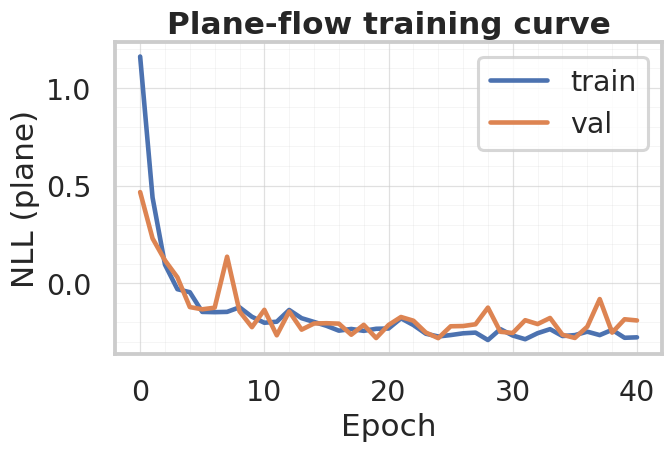

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
epochs = jnp.arange(len(losses["train"]))
ax.plot(epochs, losses["train"], label="train", color=palette[0])
ax.plot(epochs, losses["val"], label="val", color=palette[1])
ax.set_xlabel("Epoch")
ax.set_ylabel("NLL (plane)")
ax.set_title("Plane-flow training curve")
ax.legend()
style_axes(ax)
plt.show()

## 4. Push samples back to the sphere

The change-of-variables formula gives the sphere density:

$$\log p_{S^2}(x) \;=\; \log p_\text{plane}\bigl(\sigma(x)\bigr) \;+\; \log\,|\det J_\sigma(x)|
  \;=\; \log p_\text{plane}\bigl(\sigma(x)\bigr) - 2\log(1 - x_3).$$

Sampling: draw $u \sim p_\text{plane}$ from the trained flow, then
$x = \sigma^{-1}(u)$ lands on $S^2$ with the right density automatically.

In [8]:
def sphere_log_prob(x: jnp.ndarray) -> jnp.ndarray:
    u, log_det = stereographic(x)
    return trained_plane.log_prob(u) + log_det


def sphere_sample(rng_key, n: int) -> jnp.ndarray:
    u = trained_plane.sample(rng_key, (n,))
    return jax.vmap(lambda u_i: inverse_stereographic(u_i)[0])(u)


sphere_samples = sphere_sample(sample_key, 2000)
print("sphere sample shape:", sphere_samples.shape)
print(
    "on-sphere check max |‖y‖ - 1|:",
    float(jnp.max(jnp.abs(jnp.linalg.norm(sphere_samples, axis=-1) - 1.0))),
)

sphere sample shape: (2000, 3)


on-sphere check max |‖y‖ - 1|: 1.1920928955078125e-07


## 5. Visualise on a Mollweide projection

Convert $(x_1, x_2, x_3)$ on $S^2$ to (longitude, latitude) and plot data
and flow samples side by side. We also draw a density heatmap by evaluating
`sphere_dist.log_prob` on a (lon, lat) grid.

In [9]:
def cartesian_to_lonlat(xyz: jnp.ndarray) -> tuple[jnp.ndarray, jnp.ndarray]:
    lon = jnp.arctan2(xyz[..., 1], xyz[..., 0])
    lat = jnp.arcsin(jnp.clip(xyz[..., 2], -1.0, 1.0))
    return lon, lat


def lonlat_to_cartesian(lon: jnp.ndarray, lat: jnp.ndarray) -> jnp.ndarray:
    return jnp.stack(
        [jnp.cos(lat) * jnp.cos(lon), jnp.cos(lat) * jnp.sin(lon), jnp.sin(lat)],
        axis=-1,
    )


lon_d, lat_d = cartesian_to_lonlat(sphere_data)
lon_s, lat_s = cartesian_to_lonlat(sphere_samples)

# Density grid in (lon, lat).
n_lon, n_lat = 180, 90
lon_grid = jnp.linspace(-jnp.pi + 1e-3, jnp.pi - 1e-3, n_lon)
lat_grid = jnp.linspace(-jnp.pi / 2 + 1e-2, jnp.pi / 2 - 1e-2, n_lat)
LON, LAT = jnp.meshgrid(lon_grid, lat_grid)
grid_xyz = lonlat_to_cartesian(LON.ravel(), LAT.ravel())


@eqx.filter_jit
def grid_log_prob(pts):
    return jax.vmap(sphere_log_prob)(pts)


grid_lp = grid_log_prob(grid_xyz).reshape(n_lat, n_lon)
density = jnp.exp(grid_lp)

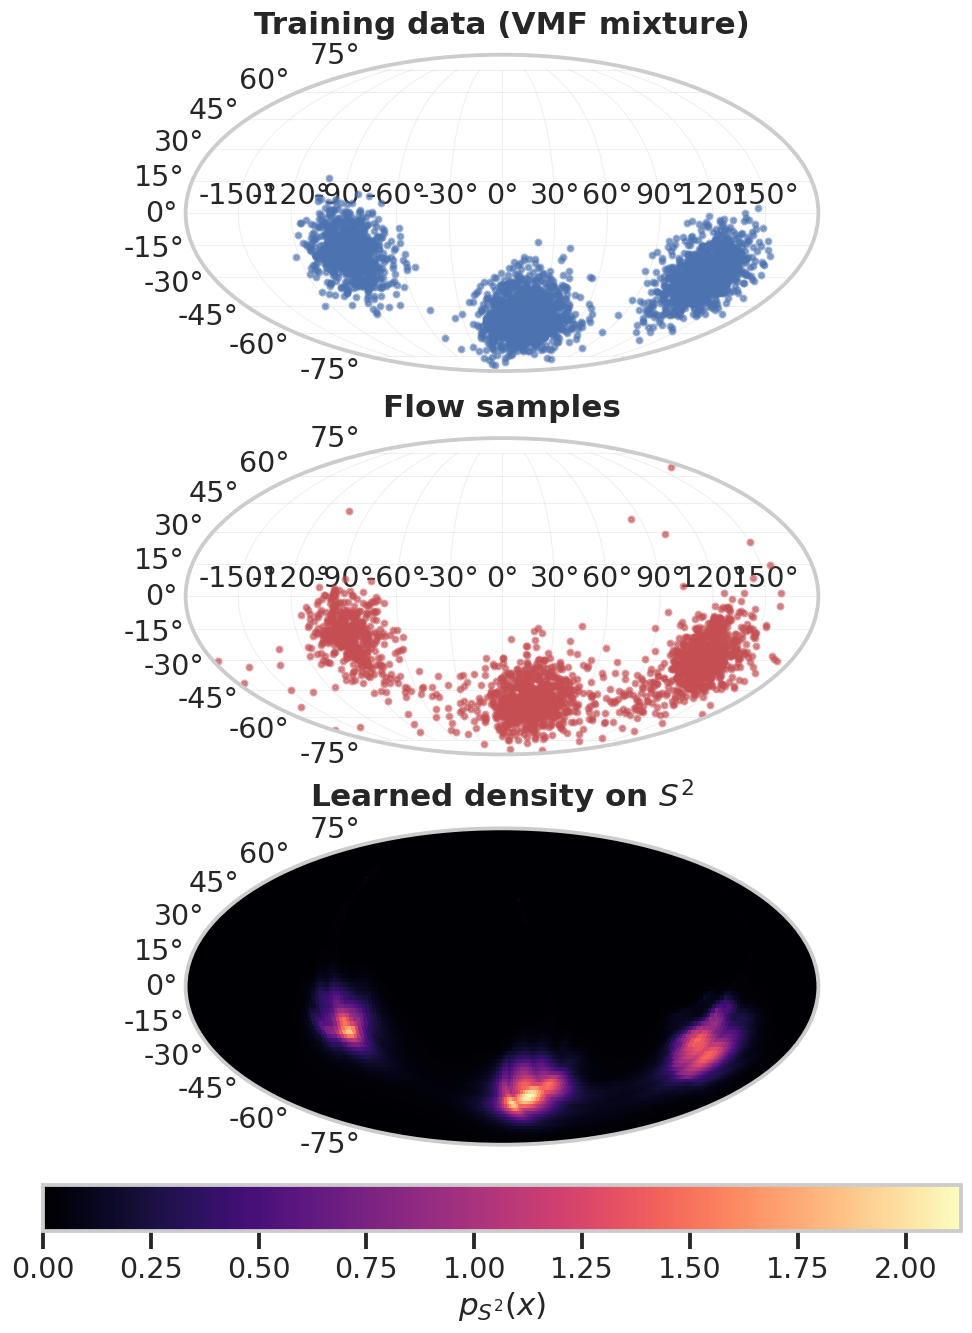

In [10]:
fig = plt.figure(figsize=(14, 12))
ax_d = fig.add_subplot(3, 1, 1, projection="mollweide")
ax_s = fig.add_subplot(3, 1, 2, projection="mollweide")
ax_p = fig.add_subplot(3, 1, 3, projection="mollweide")

ax_d.scatter(np.asarray(lon_d), np.asarray(lat_d), s=10, alpha=0.55, color=palette[0])
ax_d.set_title("Training data (VMF mixture)", pad=14)
ax_d.grid(True, alpha=0.3)

ax_s.scatter(np.asarray(lon_s), np.asarray(lat_s), s=10, alpha=0.55, color=palette[3])
ax_s.set_title("Flow samples", pad=14)
ax_s.grid(True, alpha=0.3)

mesh = ax_p.pcolormesh(
    np.asarray(LON), np.asarray(LAT), np.asarray(density), shading="auto", cmap="magma"
)
ax_p.set_title(r"Learned density on $S^2$", pad=14)
ax_p.grid(True, alpha=0.3)
fig.colorbar(
    mesh, ax=ax_p, orientation="horizontal", pad=0.08, label=r"$p_{S^2}(x)$", shrink=0.6
)
plt.show()

The flow samples cluster around the same three hotspots as the training
data, and the Mollweide density heatmap recovers the three modes. Density
values away from the modes are tiny (the colormap is dominated by the
peaks).

## 6. Sanity check: the log-density integrates to ≈ 1 on the sphere

A correct density on $S^2$ should integrate to 1 against the surface area
element $\cos(\text{lat})\,d\text{lon}\,d\text{lat}$. We approximate this on
the same (lon, lat) grid.

In [11]:
weights = jnp.cos(LAT)
dlon = (2 * jnp.pi) / n_lon
dlat = jnp.pi / n_lat
total = float(jnp.sum(density * weights) * dlon * dlat)
print(f"∫_S² p(x) dA  ≈  {total:.4f}")

∫_S² p(x) dA  ≈  0.9902


We don't expect exactly 1 because the grid skips a thin equatorial band near
the projection-pole singularity and uses a coarse mesh — but the integral
should land in the ballpark of 1, confirming the Jacobian bookkeeping is
right.

## 7. What's going on under the hood

- **Plane flow**: a standard `Transformed(Normal, RQSplineCoupling chain)`
  trained on stereographically-projected data. Nothing special.
- **Sphere log-density**: composed manually via change of variables.
  `sphere_log_prob(x) = plane.log_prob(σ(x)) + log|det J_σ(x)|`.
- **Sphere sampling**: $u \sim p_\text{plane}$, then $x = \sigma^{-1}(u)$.
- **Where stereographic helps**: any flat-space flow (`RQSplineCoupling`
  here, but `FFJORD`, `MatrixExponential`, `gaussianization_flow`, … all
  work) can be reused without writing a sphere-native bijection.
- **Where it bites**: data near the projection pole maps to large
  $\|u\|$, the spline coupling has finite support, and the Jacobian
  $\propto 1/(1 + \|u\|^2)^2$ collapses. For globally distributed data
  you'd want a **two-chart** (north + south) construction or a
  tangent-space (`expmap`) flow — see the
  [`tangent_basis` / `expmap_sphere`](../api/index.md) utilities for the
  building blocks.